# Data Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Project paths
PROJECT_DIR = Path("..")

DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "clean"
OUTPUT_DIR = PROJECT_DIR / "outputs"

# File paths
CLEAN_DATA = CLEAN_DIR / "upi_transactions_clean.csv"

USER_FREQUENCY = OUTPUT_DIR / "01_user_transaction_frequency.csv"
RECEIVER_ANALYSIS = OUTPUT_DIR / "02_receiver_concentration.csv"
SHARED_DEVICES = OUTPUT_DIR / "03_shared_devices.csv"
TRANSACTION_BURSTS = OUTPUT_DIR / "04_transaction_bursts.csv"
HIGH_VALUE = OUTPUT_DIR / "05_high_value_transactions.csv"
SUSPICIOUS_SIGNALS = OUTPUT_DIR / "06_combined_suspicious_signals.csv"
TOTAL_OUTCOMES = OUTPUT_DIR / "total_outcomes.csv"

In [7]:
df = pd.read_csv(CLEAN_DATA)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Dataset shape: (50000, 11)

Columns:
['transaction_id', 'user_id', 'timestamp', 'amount', 'transaction_type', 'merchant_category', 'merchant_id', 'city', 'device_id', 'status', 'receiver_id']


,transaction_id,user_id,timestamp,amount,transaction_type,merchant_category,merchant_id,city,device_id,status,receiver_id
0,TXN00037414,U01112,2026-01-01 00:08:00,289.59,P2M,Healthcare,M01383,Delhi,D00790,SUCCESS,M01383
1,TXN00029422,U01252,2026-01-01 00:11:00,77.56,P2M,Fuel,M00389,Ahmedabad,D01414,SUCCESS,M00389
2,TXN00026757,U00488,2026-01-01 00:11:00,154.65,P2P,P2P,NaN,Mumbai,D04419,SUCCESS,U01599
3,TXN00005630,U02139,2026-01-01 00:22:00,273.63,P2P,P2P,NaN,Ahmedabad,D03775,SUCCESS,U03408
4,TXN00009067,U02122,2026-01-01 00:27:00,93.49,P2P,P2P,NaN,Chennai,D03238,SUCCESS,U04199


In [8]:
user_frequency = pd.read_csv(USER_FREQUENCY)
receiver_analysis = pd.read_csv(RECEIVER_ANALYSIS)
shared_devices = pd.read_csv(SHARED_DEVICES)
transaction_bursts = pd.read_csv(TRANSACTION_BURSTS)
high_value = pd.read_csv(HIGH_VALUE)
suspicious_signals = pd.read_csv(SUSPICIOUS_SIGNALS)
total_outcomes = pd.read_csv(TOTAL_OUTCOMES)

In [9]:
print("User frequency:", user_frequency.shape)
print("Receiver analysis:", receiver_analysis.shape)
print("Shared devices:", shared_devices.shape)
print("Transaction bursts:", transaction_bursts.shape)
print("High-value transactions:", high_value.shape)
print("Suspicious signals:", suspicious_signals.shape)

User frequency: (5000, 4)
Receiver analysis: (6365, 4)
Shared devices: (1378, 4)
Transaction bursts: (2, 4)
High-value transactions: (2141, 7)
Suspicious signals: (44510, 10)


In [10]:
user_frequency.head(10)

,user_id,transaction_count,total_transaction_value,average_transaction_amount
0,U04461,27,6345.38,235.01
1,U04702,23,6644.35,288.88
2,U02095,22,6336.07,288.00
3,U03397,22,6950.79,315.95
4,U04163,21,5514.48,262.59
5,U00428,21,9589.09,456.62
6,U00245,21,6886.91,327.95
7,U04303,21,4809.35,229.02
8,U01417,21,3851.48,183.40
9,U03796,20,4482.36,224.12


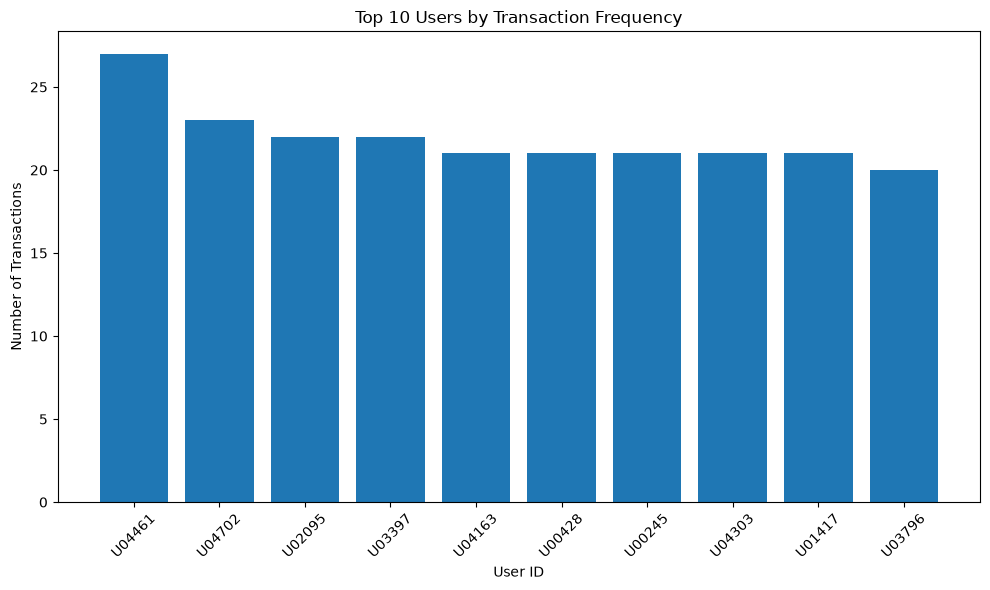

In [11]:
top_users = user_frequency.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_users["user_id"].astype(str),
    top_users["transaction_count"]
)

plt.title("Top 10 Users by Transaction Frequency")
plt.xlabel("User ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
receiver_analysis.head(10)

,receiver_id,transaction_count,unique_users,total_received
0,M00589,41,41,12984.61
1,M00226,38,38,10947.61
2,M00429,37,37,13432.91
3,M00871,37,37,12354.15
4,M00619,36,36,10398.73
5,M00449,35,35,11566.64
6,M00469,35,35,9395.88
7,M00862,35,34,10666.01
8,M00117,34,34,8667.36
9,M00707,34,34,8348.70


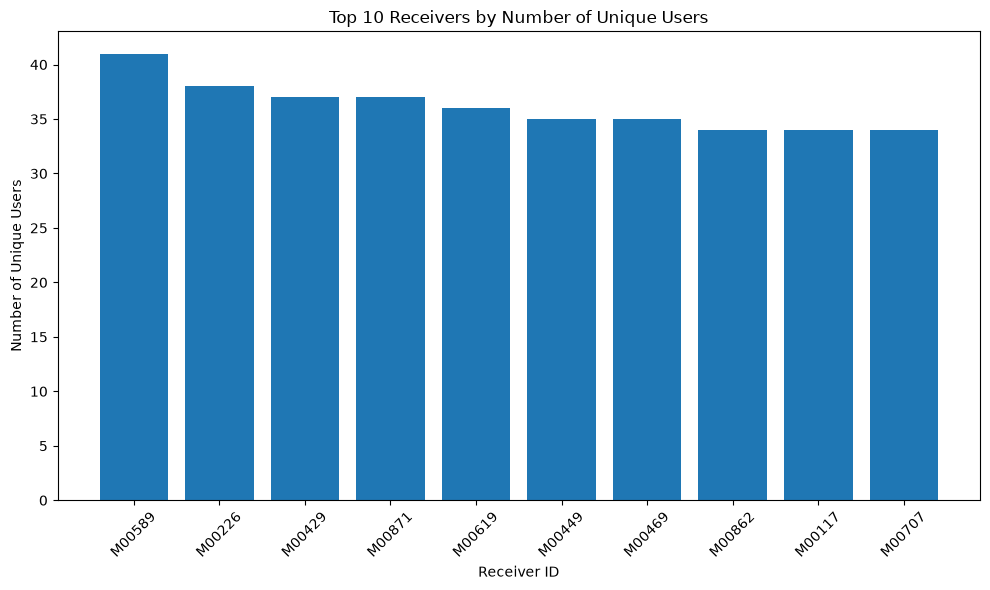

In [13]:
top_receivers = receiver_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_receivers["receiver_id"].astype(str),
    top_receivers["unique_users"]
)

plt.title("Top 10 Receivers by Number of Unique Users")
plt.xlabel("Receiver ID")
plt.ylabel("Number of Unique Users")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
shared_devices.head(10)

,device_id,unique_users,transaction_count,total_transaction_value
0,D00703,6,67,22806.47
1,D03703,6,56,13926.16
2,D02650,6,66,21180.23
3,D01435,6,63,14148.42
4,D00695,6,65,17503.72
5,D00741,5,54,14435.45
6,D02706,5,45,11710.52
7,D04429,5,44,13742.67
8,D01397,5,46,12786.97
9,D01218,5,40,11212.66


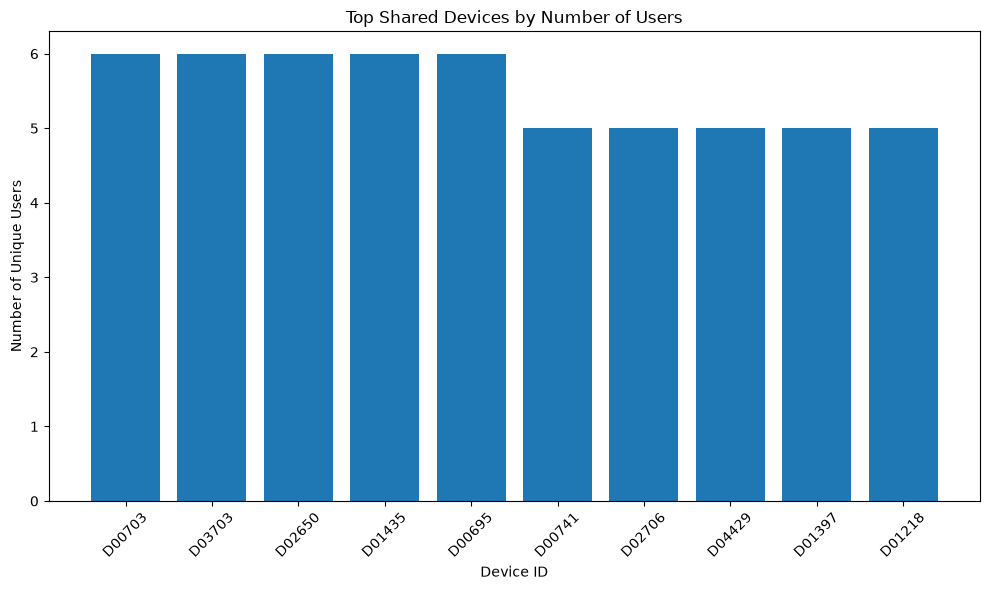

In [15]:
top_devices = shared_devices.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_devices["device_id"].astype(str),
    top_devices["unique_users"]
)

plt.title("Top Shared Devices by Number of Users")
plt.xlabel("Device ID")
plt.ylabel("Number of Unique Users")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
transaction_bursts.head(10)

,user_id,transaction_period,transaction_count,total_transaction_value
0,U04991,15-03-2026 02:15,5,2018.11
1,U04991,15-03-2026 02:10,5,2104.14


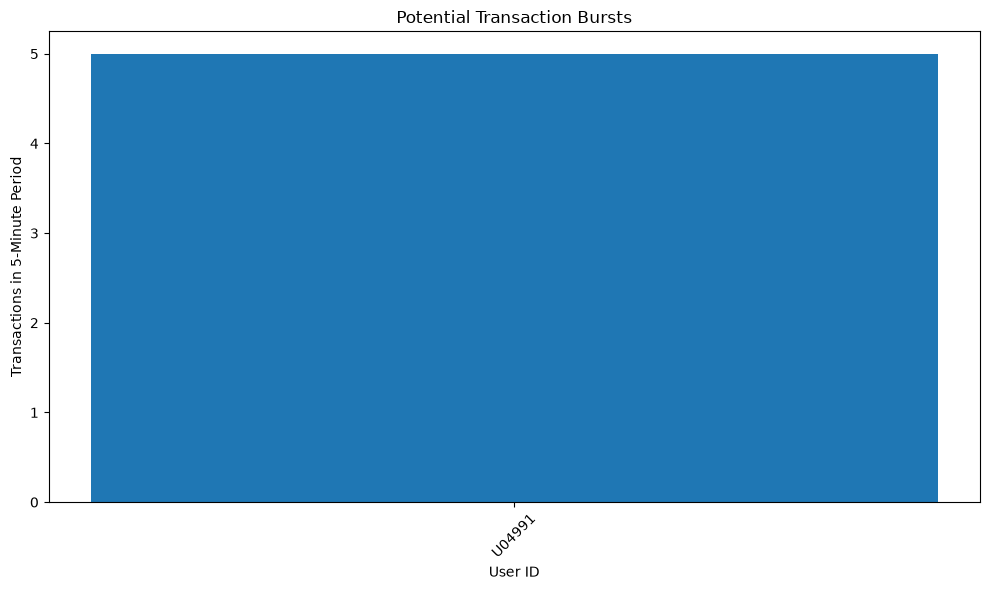

In [17]:
if transaction_bursts.empty:
    print("No transaction bursts were detected.")
else:
    burst_data = transaction_bursts.sort_values(
        "transaction_count",
        ascending=False
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        burst_data["user_id"].astype(str),
        burst_data["transaction_count"]
    )

    plt.title("Potential Transaction Bursts")
    plt.xlabel("User ID")
    plt.ylabel("Transactions in 5-Minute Period")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [18]:
high_value.head(10)

,transaction_id,user_id,receiver_id,amount,timestamp,transaction_type,status
0,TXN00015844,U02760,M01223,9020.20,2026-06-27 09:19:00,P2M,PENDING
1,TXN00001490,U04970,M00848,8576.27,2026-06-05 03:06:00,P2M,SUCCESS
2,TXN00029521,U04970,M00876,7970.06,2026-06-05 02:45:00,P2M,SUCCESS
3,TXN00036410,U04970,M01012,7854.50,2026-06-05 02:52:00,P2M,SUCCESS
4,TXN00038041,U04970,U00728,7670.98,2026-06-05 03:13:00,P2P,SUCCESS
5,TXN00015731,U04970,M00039,7259.63,2026-06-05 02:59:00,P2M,SUCCESS
6,TXN00018852,U00953,M01089,5715.75,2026-03-16 17:44:00,P2M,SUCCESS
7,TXN00002896,U02347,M01067,5638.10,2026-01-20 21:52:00,P2M,SUCCESS
8,TXN00000210,U00680,U00771,5296.61,2026-06-01 05:04:00,P2P,SUCCESS
9,TXN00033321,U02209,U02089,4763.12,2026-01-17 18:27:00,P2P,SUCCESS


In [19]:
average_amount = df["amount"].mean()
high_value_threshold = average_amount * 3

print("Average transaction amount:", round(average_amount, 2))
print("High-value threshold:", round(high_value_threshold, 2))
print("Number of high-value transactions:", len(high_value))

Average transaction amount: 288.16
High-value threshold: 864.48
Number of high-value transactions: 2141


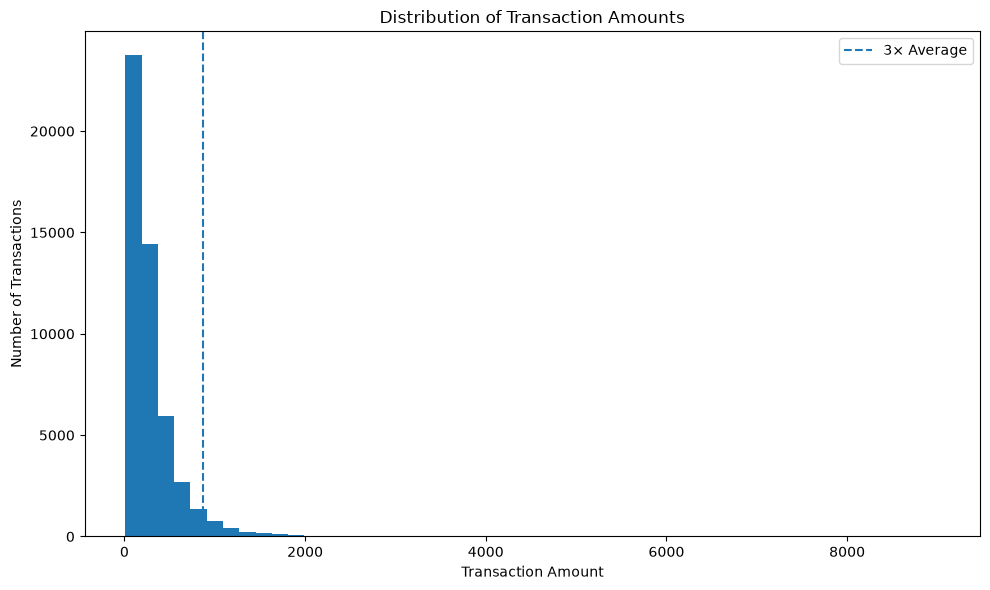

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["amount"],
    bins=50
)

plt.axvline(
    high_value_threshold,
    linestyle="--",
    label="3× Average"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
suspicious_signals.head()

,transaction_id,user_id,receiver_id,device_id,amount,timestamp,high_value_flag,frequent_user_flag,high_receiver_flag,shared_device_flag
0,TXN00015844,U02760,M01223,D02009,9020.20,2026-06-27 09:19:00,1,0,1,1
1,TXN00001490,U04970,M00848,D00857,8576.27,2026-06-05 03:06:00,1,0,1,1
2,TXN00029521,U04970,M00876,D00857,7970.06,2026-06-05 02:45:00,1,0,1,1
3,TXN00036410,U04970,M01012,D00857,7854.50,2026-06-05 02:52:00,1,0,1,1
4,TXN00038041,U04970,U00728,D00857,7670.98,2026-06-05 03:13:00,1,0,0,1


In [22]:
signal_columns = [
    "high_value_flag",
    "frequent_user_flag",
    "high_receiver_flag",
    "shared_device_flag"
]

suspicious_signals["signal_count"] = (
    suspicious_signals[signal_columns]
    .sum(axis=1)
)

suspicious_signals.head()

,transaction_id,user_id,receiver_id,device_id,amount,timestamp,high_value_flag,frequent_user_flag,high_receiver_flag,shared_device_flag,signal_count
0,TXN00015844,U02760,M01223,D02009,9020.20,2026-06-27 09:19:00,1,0,1,1,3
1,TXN00001490,U04970,M00848,D00857,8576.27,2026-06-05 03:06:00,1,0,1,1,3
2,TXN00029521,U04970,M00876,D00857,7970.06,2026-06-05 02:45:00,1,0,1,1,3
3,TXN00036410,U04970,M01012,D00857,7854.50,2026-06-05 02:52:00,1,0,1,1,3
4,TXN00038041,U04970,U00728,D00857,7670.98,2026-06-05 03:13:00,1,0,0,1,2


In [26]:
signal_distribution = (
    suspicious_signals["signal_count"]
    .value_counts()
    .sort_index()
)

signal_distribution

signal_count
1    21478
2    21920
3     1105
4        7
Name: count, dtype: int64

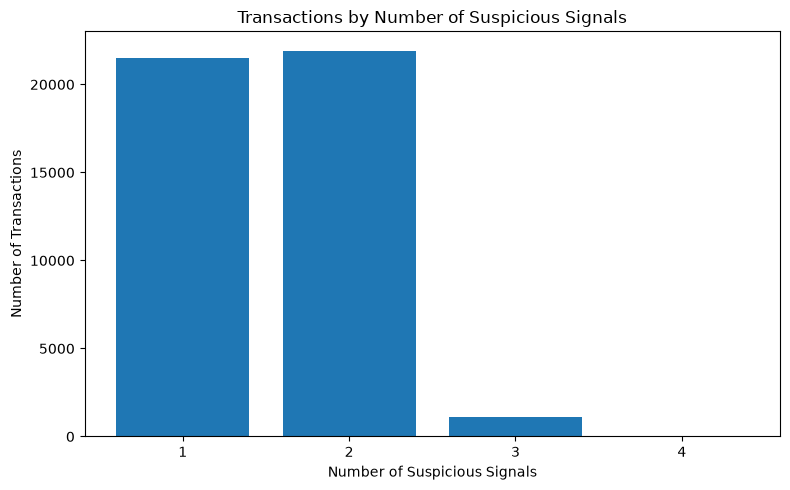

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    signal_distribution.index.astype(str),
    signal_distribution.values
)

plt.title("Transactions by Number of Suspicious Signals")
plt.xlabel("Number of Suspicious Signals")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [ ]:
suspicious_signals["timestamp"] = pd.to_datetime(
    suspicious_signals["timestamp"]
)

suspicious_signals["hour"] = (
    suspicious_signals["timestamp"].dt.hour
)
hourly_suspicious = (
    suspicious_signals
    .groupby("hour")
    .size()
)

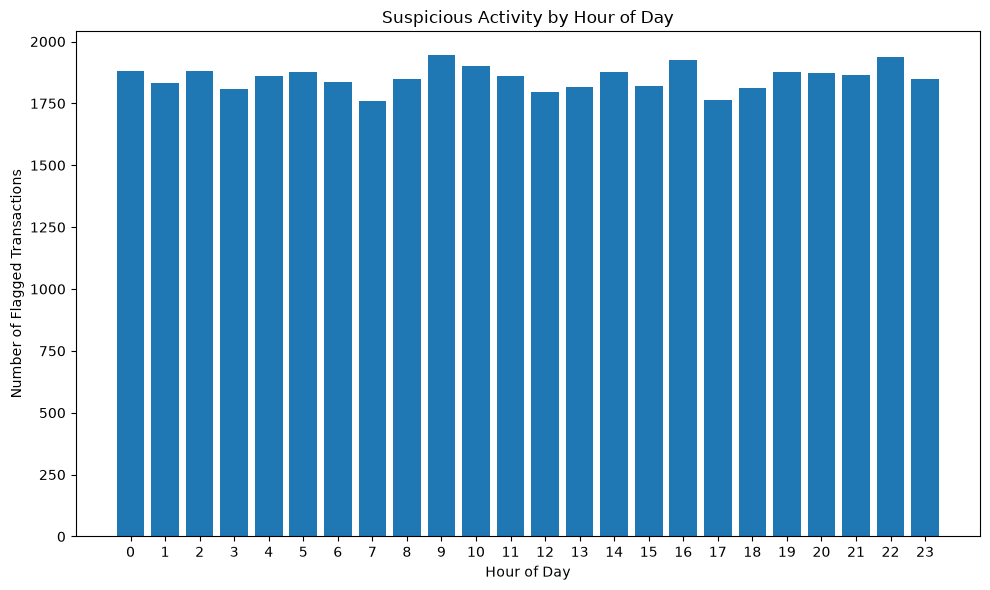

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    hourly_suspicious.index,
    hourly_suspicious.values
)

plt.title("Suspicious Activity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flagged Transactions")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [32]:
total_flagged_value = suspicious_signals["amount"].sum()

print(
    f"Potentially exposed transaction value: ₹{total_flagged_value:,.2f}"
)

Potentially exposed transaction value: ₹13,092,242.47


In [33]:
total_transaction_value = df["amount"].sum()

exposure_percentage = (
    total_flagged_value / total_transaction_value
) * 100

print(
    f"Total transaction value: ₹{total_transaction_value:,.2f}"
)

print(
    f"Potentially exposed percentage: {exposure_percentage:.2f}%"
)

Total transaction value: ₹14,407,944.65
Potentially exposed percentage: 90.87%


In [34]:
python_output = OUTPUT_DIR / "07_python_suspicion_analysis.csv"

suspicious_signals.to_csv(
    python_output,
    index=False
)

print(f"Saved to: {python_output}")

Saved to: ..\outputs\07_python_suspicion_analysis.csv
